# Import Data

### Issues with data
I identified 14 games for which there was no goalie pull event in the data, but which there was clearly a goalie pull in the youtube video broadcast. Those goalie events were added manually with my best guess for the time based on the broadcast.

Edge case: Goals that were scored at even strength after the goalie was pulled but put back were NOT counted as goals with an extra attacker.

### Data source
365HockeyGirl Github: https://github.com/365hockeygirl/pwhl-pulling-the-goalie/tree/main

data available in `goalie_pulls_df`

In [ ]:
import pandas as pd
url = 'https://raw.githubusercontent.com/365hockeygirl/pwhl-pulling-the-goalie/refs/heads/main/data/s3_goalie_pulls_with_goals.csv'
goalie_pulls_df = pd.read_csv(url)

In [ ]:
goalie_pulls_df

,time_remaining,game_date,home_team_name,away_team_name,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,team_name,added_manually,total_minutes_in_game,pulling_team_name,extra_attacker_goals,empty_net_goals,scored_extra_attacker_goal,scored_empty_net_goal
0,1.200000,"Friday, November 21, 2025",Minnesota Frost,Toronto Sceptres,210,2,3,18:48,NaN,123,NaN,Rooney,NaN,False,58.800000,Minnesota Frost,[],[],False,False
1,2.116667,"Friday, November 21, 2025",Vancouver Goldeneyes,Seattle Torrent,211,9,3,17:53,NaN,59,NaN,Maschmeyer,NaN,False,57.883333,Vancouver Goldeneyes,[1066],[],True,False
2,2.833333,"Saturday, November 22, 2025",Ottawa Charge,New York Sirens,212,5,3,17:10,NaN,222,NaN,Philips,NaN,False,57.166667,Ottawa Charge,[],[1071],False,True
3,2.850000,"Sunday, November 23, 2025",Boston Fleet,Montréal Victoire,213,3,3,17:09,NaN,28,NaN,Desbiens,NaN,False,57.150000,Montréal Victoire,[],[],False,False
4,4.350000,"Tuesday, November 25, 2025",Montréal Victoire,New York Sirens,214,4,3,15:39,NaN,228,NaN,Osborne,NaN,False,55.650000,New York Sirens,[],[1078],False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,1.333333,"Tuesday, April 21, 2026",Toronto Sceptres,New York Sirens,322,4,3,18:40,NaN,228,NaN,Osborne,NaN,False,58.666667,New York Sirens,[],[],False,False
78,8.183333,"Tuesday, April 21, 2026",Vancouver Goldeneyes,Montréal Victoire,323,3,3,11:49,NaN,48,NaN,Abstreiter,NaN,False,51.816667,Montréal Victoire,"[1593, 1594, 1595]",[],True,False
79,2.266667,"Wednesday, April 22, 2026",Seattle Torrent,Minnesota Frost,325,2,3,17:44,NaN,22,NaN,Hensley,NaN,False,57.733333,Minnesota Frost,[1607],[],True,False
80,5.716667,"Saturday, April 25, 2026",Ottawa Charge,Toronto Sceptres,328,6,3,14:17,NaN,211,NaN,Kirk,NaN,False,54.283333,Toronto Sceptres,[],[1614],False,True


In [ ]:
len(goalie_pulls_df)

82

In [ ]:
list(goalie_pulls_df.columns)

['time_remaining',
 'game_date',
 'home_team_name',
 'away_team_name',
 'game_id',
 'team_id',
 'period_id',
 'time',
 'goalie_in_id',
 'goalie_out_id',
 'goalie_in_info.last_name',
 'goalie_out_info.last_name',
 'team_name',
 'added_manually',
 'total_minutes_in_game',
 'pulling_team_name',
 'extra_attacker_goals',
 'empty_net_goals',
 'scored_extra_attacker_goal',
 'scored_empty_net_goal']

In [ ]:
url = 'https://raw.githubusercontent.com/365hockeygirl/pwhl-pulling-the-goalie/refs/heads/main/data/s3_extra_attacker_goals.csv'
extra_attacker_df = pd.read_csv(url)

In [ ]:
# drop game ids that don't match with the goalie pulls
extra_attacker_df = extra_attacker_df[extra_attacker_df['game_id'].isin(goalie_pulls_df['game_id'])]

In [ ]:
manually_added_pulls = goalie_pulls_df[goalie_pulls_df['added_manually'] == True]

In [ ]:
manually_added_pulls

,time_remaining,game_date,home_team_name,away_team_name,game_id,team_id,period_id,time,goalie_in_id,goalie_out_id,goalie_in_info.last_name,goalie_out_info.last_name,team_name,added_manually,total_minutes_in_game,pulling_team_name,extra_attacker_goals,empty_net_goals,scored_extra_attacker_goal,scored_empty_net_goal
6,3.466667,"Friday, November 28, 2025",Seattle Torrent,Minnesota Frost,216,8,3,16:32,NaN,155,NaN,Schroeder,Seattle Torrent,True,56.533333,Seattle Torrent,[],[],False,False
14,3.833333,"Wednesday, December 17, 2025",Seattle Torrent,Ottawa Charge,229,5,3,16:10,NaN,238,NaN,Ahola,Ottawa Charge,True,56.166667,Ottawa Charge,[],[1139],False,True
18,2.916667,"Sunday, December 21, 2025",Seattle Torrent,Boston Fleet,234,8,3,17:05,NaN,155,NaN,Schroeder,Seattle Torrent,True,57.083333,Seattle Torrent,[1169],[],True,False
19,2.566667,"Tuesday, December 23, 2025",Seattle Torrent,Montréal Victoire,236,3,3,17:26,NaN,28,NaN,Desbiens,Montréal Victoire,True,57.433333,Montréal Victoire,[],[],False,False
25,3.083333,"Saturday, January 3, 2026",Ottawa Charge,Minnesota Frost,244,2,3,16:55,NaN,123,NaN,Rooney,Minnesota Frost,True,56.916667,Minnesota Frost,[],[1222],False,True
26,1.183333,"Saturday, January 3, 2026",Boston Fleet,Vancouver Goldeneyes,246,1,3,18:49,NaN,6,NaN,Frankel,Boston Fleet,True,58.816667,Boston Fleet,[],[],False,False
35,1.550000,"Tuesday, January 20, 2026",Seattle Torrent,Toronto Sceptres,261,6,3,18:27,NaN,211,NaN,Kirk,Toronto Sceptres,True,58.450000,Toronto Sceptres,[],[],False,False
42,2.200000,"Friday, February 27, 2026",Seattle Torrent,Toronto Sceptres,272,8,3,17:48,NaN,250,NaN,Murphy,Seattle Torrent,True,57.800000,Seattle Torrent,[],"[1355, 1356]",False,True
46,2.550000,"Thursday, March 5, 2026",New York Sirens,Boston Fleet,278,4,3,17:27,NaN,228,NaN,Osborne,New York Sirens,True,57.450000,New York Sirens,[],[],False,False
49,1.183333,"Wednesday, March 11, 2026",Seattle Torrent,Boston Fleet,283,1,3,18:49,NaN,41,NaN,Levy,Boston Fleet,True,58.816667,Boston Fleet,[],[],False,False


In [ ]:
url = 'https://raw.githubusercontent.com/365hockeygirl/pwhl-pulling-the-goalie/refs/heads/main/data/goalie_pull_goal_differential.csv'
goal_differential_df = pd.read_csv(url)

In [ ]:
# General PWHL info
S3_TOTAL_GAMES_LENGTH = 120

### Color palette

[color palettes](https://www.geeksforgeeks.org/data-visualization/color-palettes-for-data-visualization/)

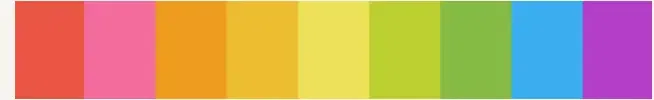

In [ ]:
retro_metro = ["#ea5545", "#f46a9b", "#ef9b20", "#edbf33", "#ede15b", "#bdcf32", "#87bc45", "#27aeef", "#b33dc6" ]

red = retro_metro[0]
pink = retro_metro[1]
blue = retro_metro[7]
yellow = retro_metro[4]
green = retro_metro[6]
gray = "#d7e1ee"

In [ ]:
team_color_map = {
      "Seattle Torrent": "teal",
      "Toronto Sceptres": "RoyalBlue",
      "Boston Fleet": "green",
      "Montréal Victoire": "maroon",
      "Hamilton": "gold",
      "Detroit": "black",
      "Las Vegas": "Olive",
      "San Jose": "DeepSkyBlue",
      "Minnesota Frost": "MediumSlateBlue",
      "Ottawa Charge": "Crimson",
      "Vancouver Goldeneyes": "MediumBlue",
      "New York Sirens": "LightSeaGreen",
    };

# Exploratory Analysis

### What percent of the games featured a goalie pull?

In [ ]:
len(goalie_pulls_df)

82

In [ ]:
S3_TOTAL_GAMES_LENGTH

120

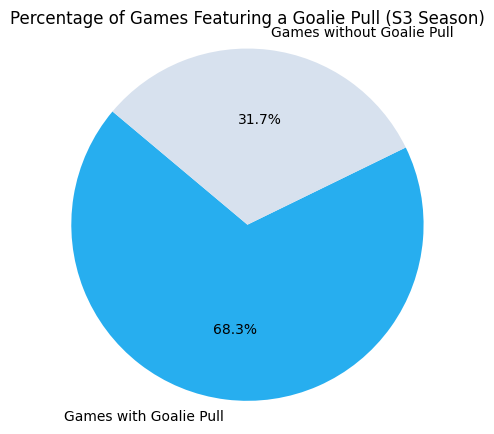

Total games: 120
Games with a goalie pull: 82
Percentage of games with a goalie pull: 68.33%


In [ ]:
import matplotlib.pyplot as plt

# Calculate the number of games with goalie pulls
games_with_pull = len(goalie_pulls_df)

# Calculate the number of games without goalie pulls
games_without_pull = S3_TOTAL_GAMES_LENGTH - games_with_pull

# Data for the pie chart
labels = ['Games with Goalie Pull', 'Games without Goalie Pull']
sizes = [games_with_pull, games_without_pull]
colors = [blue,gray]
# explode = (0.1, 0)  # Explode the 'Games with Goalie Pull' slice - Removed as requested

# Create the pie chart
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title('Percentage of Games Featuring a Goalie Pull (S3 Season)')
plt.show()

print(f"Total games: {S3_TOTAL_GAMES_LENGTH}")
print(f"Games with a goalie pull: {games_with_pull}")
print(f"Percentage of games with a goalie pull: {(games_with_pull / S3_TOTAL_GAMES_LENGTH) * 100:.2f}%")

# Goalie Pull Success

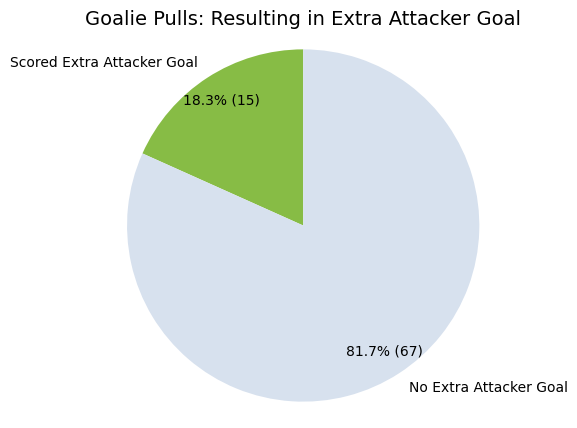

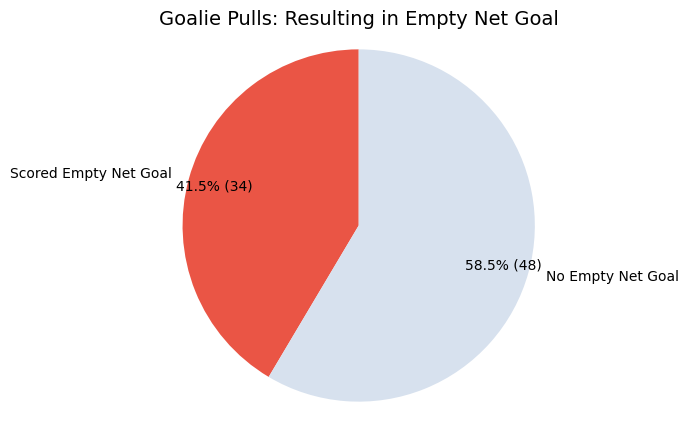

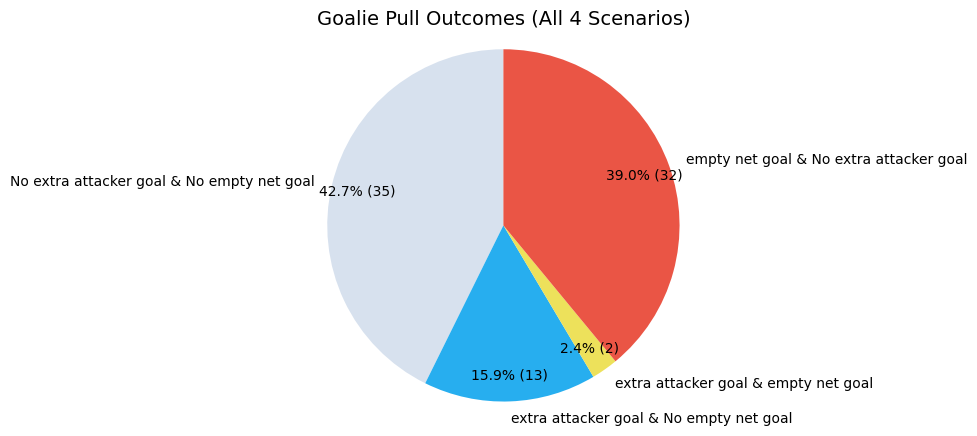

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert 'TRUE'/'FALSE' strings to actual boolean values
goalie_pulls_df['scored_extra_attacker_goal'] = goalie_pulls_df['scored_extra_attacker_goal'].astype(str).str.upper() == 'TRUE'
goalie_pulls_df['scored_empty_net_goal'] = goalie_pulls_df['scored_empty_net_goal'].astype(str).str.upper() == 'TRUE'

def create_pie_chart(ax, sizes, labels, title, colors=None, startangle=90, show_external_labels=False):
    """Reusable function to create a pie chart on a given axes object.
    Returns the patches from the pie chart for use in a legend."""

    # Custom autopct to include both percentage and count, hiding text if count is 0
    def autopct_format(pct):
        total = sum(sizes)
        val = int(round(pct*total/100.0))
        if val == 0:
            return ''
        return f'{pct:.1f}% ({val:d})'

    # Plot the pie chart using all original sizes and colors to maintain color mapping
    # Pass labels=None to hide the external labels, autopct handles internal text.
    pie_labels = labels if show_external_labels else None

    if colors:
        patches, texts, autotexts = ax.pie(
            sizes,
            labels=pie_labels, # Use external labels if requested
            colors=colors,         # Use original colors
            autopct=autopct_format,
            startangle=startangle,
            pctdistance=0.85     # Adjust distance for percentage labels
        )
    else:
        patches, texts, autotexts = ax.pie(
            sizes,
            labels=pie_labels, # Use external labels if requested
            autopct=autopct_format,
            startangle=startangle,
            pctdistance=0.85
        )

    # Ensure autotexts are hidden if their size is zero (already handled by autopct_format, but as a safeguard).
    for i, size in enumerate(sizes):
        if size == 0 and autotexts:
            autotexts[i].set_visible(False)

    ax.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    ax.set_title(title, fontsize=14) # Increased title font size
    return patches

# --- Chart 1: Extra Attacker Goal vs. No Extra Attacker Goal ---

eag_true = goalie_pulls_df['scored_extra_attacker_goal'].sum()
eag_false = len(goalie_pulls_df) - eag_true

sizes_eag = [eag_true, eag_false]
labels_eag = ['Scored Extra Attacker Goal', 'No Extra Attacker Goal']
colors_eag = [green, gray] # Green for success, Orange for no success
title_eag = 'Goalie Pulls: Resulting in Extra Attacker Goal'

fig1, ax1 = plt.subplots(figsize=(5, 5))
create_pie_chart(ax1, sizes_eag, labels_eag, title_eag, colors=colors_eag, show_external_labels=True)
plt.show()

# --- Chart 2: Empty Net Goal vs. No Empty Net Goal ---

eng_true = goalie_pulls_df['scored_empty_net_goal'].sum()
eng_false = len(goalie_pulls_df) - eng_true

sizes_eng = [eng_true, eng_false]
labels_eng = ['Scored Empty Net Goal', 'No Empty Net Goal']
colors_eng = [red, gray] # Blue for success, Red for no success
title_eng = 'Goalie Pulls: Resulting in Empty Net Goal'

fig2, ax2 = plt.subplots(figsize=(5, 5))
create_pie_chart(ax2, sizes_eng, labels_eng, title_eng, colors=colors_eng, show_external_labels=True)
plt.show()

# --- Chart 3: All 4 Cases ---

# Case 1: No EAG and No ENG
case_no_eag_no_eng = goalie_pulls_df[(~goalie_pulls_df['scored_extra_attacker_goal']) & (~goalie_pulls_df['scored_empty_net_goal'])].shape[0]

# Case 2: EAG and No ENG
case_eag_no_eng = goalie_pulls_df[(goalie_pulls_df['scored_extra_attacker_goal']) & (~goalie_pulls_df['scored_empty_net_goal'])].shape[0]

# Case 3: EAG and ENG
case_eag_eng = goalie_pulls_df[(goalie_pulls_df['scored_extra_attacker_goal']) & (goalie_pulls_df['scored_empty_net_goal'])].shape[0]

# Case 4: ENG and No EAG
case_eng_no_eag = goalie_pulls_df[(~goalie_pulls_df['scored_extra_attacker_goal']) & (goalie_pulls_df['scored_empty_net_goal'])].shape[0]

sizes_four_cases = [case_no_eag_no_eng, case_eag_no_eng, case_eag_eng, case_eng_no_eag]
labels_four_cases = [
    'No extra attacker goal & No empty net goal',
    'extra attacker goal & No empty net goal',
    'extra attacker goal & empty net goal',
    'empty net goal & No extra attacker goal'
]
colors_four_cases = [gray, blue, yellow, red] # A distinct palette for multiple categories
title_four_cases = 'Goalie Pull Outcomes (All 4 Scenarios)'

fig3, ax3 = plt.subplots(figsize=(5, 5))
create_pie_chart(ax3, sizes_four_cases, labels_four_cases, title_four_cases, colors=colors_four_cases, show_external_labels=True)
plt.show()

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

unique_teams = goalie_pulls_df['pulling_team_name'].unique()
num_teams = len(unique_teams)

# Determine subplot grid: 4 rows, 2 columns for 8 teams
fig = make_subplots(
    rows=4,
    cols=2,
    specs=[[{'type':'domain'}, {'type':'domain'}],
           [{'type':'domain'}, {'type':'domain'}],
           [{'type':'domain'}, {'type':'domain'}],
           [{'type':'domain'}, {'type':'domain'}]],
    subplot_titles=[team_name for team_name in unique_teams] # Set subplot titles from team names
)

labels_four_cases = [
    'No extra attacker goal & No empty net goal',
    'extra attacker goal & No empty net goal',
    'extra attacker goal & empty net goal',
    'empty net goal & No extra attacker goal'
]
# Colors are already defined in zhLqqps_b6_2 and are globally available
# colors_four_cases = [gray, green, yellow, red]

for i, team_name in enumerate(unique_teams):
    row = i // 2 + 1
    col = i % 2 + 1

    team_df = goalie_pulls_df[goalie_pulls_df['pulling_team_name'] == team_name]

    sizes_four_cases_team = []
    hover_texts_per_slice = [] # List to hold hover text for each slice (game IDs)

    # Case 1: No EAG and No ENG
    scenario_df_1 = team_df[(~team_df['scored_extra_attacker_goal']) & (~team_df['scored_empty_net_goal'])]
    sizes_four_cases_team.append(len(scenario_df_1))
    if len(scenario_df_1) > 0:
        hover_text_1 = ", ".join([str(row_data['game_id']) for idx, row_data in scenario_df_1.iterrows()])
        hover_texts_per_slice.append(hover_text_1)
    else:
        hover_texts_per_slice.append("N/A")

    # Case 2: EAG and No ENG
    scenario_df_2 = team_df[(team_df['scored_extra_attacker_goal']) & (~team_df['scored_empty_net_goal'])]
    sizes_four_cases_team.append(len(scenario_df_2))
    if len(scenario_df_2) > 0:
        hover_text_2 = ", ".join([str(row_data['game_id']) for idx, row_data in scenario_df_2.iterrows()])
        hover_texts_per_slice.append(hover_text_2)
    else:
        hover_texts_per_slice.append("N/A")

    # Case 3: EAG and ENG
    scenario_df_3 = team_df[(team_df['scored_extra_attacker_goal']) & (team_df['scored_empty_net_goal'])]
    sizes_four_cases_team.append(len(scenario_df_3))
    if len(scenario_df_3) > 0:
        hover_text_3 = ", ".join([str(row_data['game_id']) for idx, row_data in scenario_df_3.iterrows()])
        hover_texts_per_slice.append(hover_text_3)
    else:
        hover_texts_per_slice.append("N/A")

    # Case 4: ENG and No EAG
    scenario_df_4 = team_df[(~team_df['scored_extra_attacker_goal']) & (team_df['scored_empty_net_goal'])]
    sizes_four_cases_team.append(len(scenario_df_4))
    if len(scenario_df_4) > 0:
        hover_text_4 = ", ".join([str(row_data['game_id']) for idx, row_data in scenario_df_4.iterrows()])
        hover_texts_per_slice.append(hover_text_4)
    else:
        hover_texts_per_slice.append("N/A")

    # Calculate total pulls for percentage calculation
    total_pulls_for_team = sum(sizes_four_cases_team)

    # Create custom text for slices (percentage and value, but only if value > 0)
    slice_display_texts = []
    for size_val in sizes_four_cases_team:
        if size_val > 0 and total_pulls_for_team > 0:
            percent = (size_val / total_pulls_for_team) * 100
            slice_display_texts.append(f'{percent:.1f}% ({size_val})')
        else:
            slice_display_texts.append('') # Empty string for slices with 0 value

    # Add pie chart for the current team
    fig.add_trace(go.Pie(
        labels=labels_four_cases,
        values=sizes_four_cases_team,
        marker_colors=colors_four_cases,
        name=team_name, # Keep name for legend
        hovertemplate='<b>%{label}</b><br>%{value} pulls <br>Game IDs: %{text}<extra></extra>', # Adding <extra></extra> to suppress the trace name
        text=hover_texts_per_slice, # This is where the detailed game info goes (game IDs)
        showlegend=True, # Show legend only once, will be handled globally
        sort=True, # Maintain the order of slices based on labels_four_cases
        textinfo='text', # Use custom 'text' for on-slice labels
        texttemplate=slice_display_texts, # Supply the custom text for on-slice labels using texttemplate
        textposition='outside', # Place labels outside the slices for better readability
        hoverinfo='label+value+text' # Explicitly control what's shown in hover
    ), row=row, col=col)

fig.update_layout(
    title_text='Goalie Pull Outcomes (All 4 Scenarios) by Team',
    title_font_size=32,
    title_y=0.98, # Push title almost to the very top
    title_x = 0.5,
    height=1000,
    width=1000, # Set a fixed width for the figure
    legend=dict(
        orientation="h",
        yanchor="bottom", # Anchor the bottom of the legend
        y=1.05, # Position the bottom of the legend at the top of the plot area
        xanchor="center",
        x=0.5,
        font=dict(size=12)
    ),
    margin=dict(t=150) # Increase top margin to make space for title and legend
)

fig.show()

In [ ]:
pip install kaleido==0.2.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 11.9 MB/s eta 0:00:00


In [ ]:
# did the Sirens really not score any extra attacker goals?
extra_attacker_df[extra_attacker_df['goal_team_name'] == "New York Sirens"]

,game_id,id,team_id,goal_player_id,time,time_formatted,period,game_winning,game_tieing,plus,...,goal_team_name,plus_strength,minus_strength,extra_attacker,game_date,home_team_name,away_team_name,goal_against_team_name,total_minutes_in_game,goal_scorer_full_name


# Goalie Pull Time

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_first_goalie_pull_times(df):
    """
    Generates a horizontal box plot of the first goalie pull times (in minutes remaining in the game)
    and prints summary statistics (mean, median, and full describe).

    Args:
        df (pd.DataFrame): The DataFrame containing goalie pull data with
                           'time_remaining', 'period_id', and 'game_id' columns.
    """
    # Convert time_remaining and period_id to a single 'time from start of game' metric
    # Assuming standard 20-minute periods
    df['time_from_start_of_period'] = 20 - df['time_remaining']
    df['total_time_from_game_start'] = (df['period_id'] - 1) * 20 + df['time_from_start_of_period']

    # For each game, find the earliest goalie pull time (minimum total_time_from_game_start)
    first_pull_times = df.groupby('game_id')['total_time_from_game_start'].min().reset_index()

    # Calculate minutes remaining from the total game time (60 minutes)
    first_pull_times['minutes_remaining_in_game'] = 60 - first_pull_times['total_time_from_game_start']

    # Create the horizontal box plot
    plt.figure(figsize=(10, 2)) # Adjust figure size for horizontal plot
    sns.boxplot(x=first_pull_times['minutes_remaining_in_game'], color=blue) # Use x for horizontal
    plt.title('Distribution of First Goalie Pull Times (Minutes Remaining in Game)')
    plt.xlabel('Time Remaining in Game (minutes)') # Update x-axis label
    plt.ylabel('') # Remove y-axis label for horizontal plot
    plt.grid(axis='x', linestyle='--', alpha=0.7) # Adjust grid for x-axis
    plt.show()

    # Print summary statistics
    mean_pull_time = first_pull_times['minutes_remaining_in_game'].mean()
    median_pull_time = first_pull_times['minutes_remaining_in_game'].median()

    print(f"Average (Mean) First Goalie Pull Time: {mean_pull_time:.2f} minutes remaining in game")
    print(f"Median First Goalie Pull Time: {median_pull_time:.2f} minutes remaining in game")
    print("\nFull Summary Statistics for First Goalie Pull Times (Minutes Remaining):")
    print(first_pull_times['minutes_remaining_in_game'].describe())

In [ ]:
def plot_first_goalie_pull_histogram(df, bins=10, color=blue):
    """
    Generates a histogram of the first goalie pull times (in minutes remaining in the game).

    Args:
        df (pd.DataFrame): The DataFrame containing goalie pull data with
                           'time_remaining', 'period_id', and 'game_id' columns.
        bins (int): The number of bins for the histogram.
        color (str): The color of the histogram bars.
    """
    # Convert time_remaining and period_id to a single 'time from start of game' metric
    df_temp = df.copy()
    df_temp['time_from_start_of_period'] = 20 - df_temp['time_remaining']
    df_temp['total_time_from_game_start'] = (df_temp['period_id'] - 1) * 20 + df_temp['time_from_start_of_period']

    # For each game, find the earliest goalie pull time
    first_pull_times = df_temp.groupby('game_id')['total_time_from_game_start'].min().reset_index()

    # Calculate minutes remaining from the total game time (60 minutes)
    first_pull_times['minutes_remaining_in_game'] = 60 - first_pull_times['total_time_from_game_start']

    # Create the histogram
    plt.figure(figsize=(10, 6))
    sns.histplot(x=first_pull_times['minutes_remaining_in_game'], bins=bins, color=color)
    plt.title('Distribution of First Goalie Pull Times (Minutes Remaining in Game)')
    plt.xlabel('Time Remaining in Game (minutes)')
    plt.ylabel('Number of Goalie Pulls')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

### Demonstration of the new plotting functions

Histogram of First Goalie Pull Times:


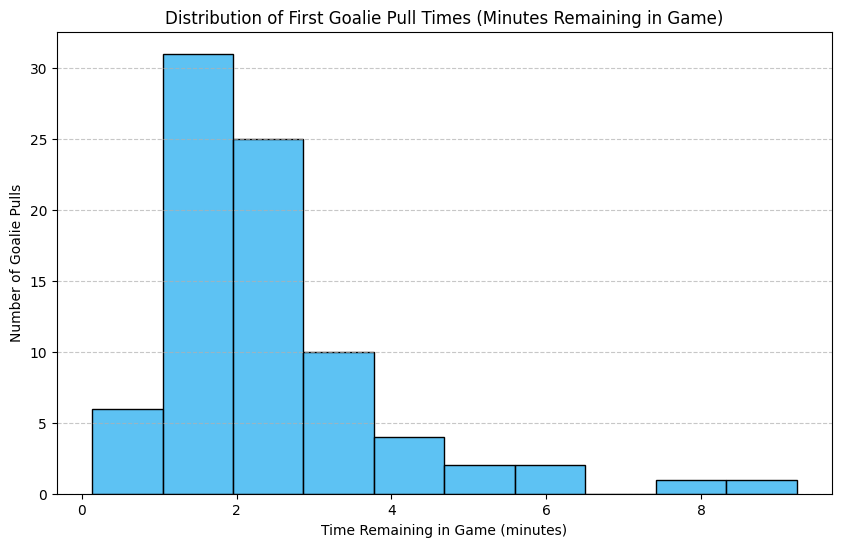

In [ ]:
# Demonstrate the histogram function
print("Histogram of First Goalie Pull Times:")
plot_first_goalie_pull_histogram(goalie_pulls_df.copy())

### Demonstration of the `plot_first_goalie_pull_times` function

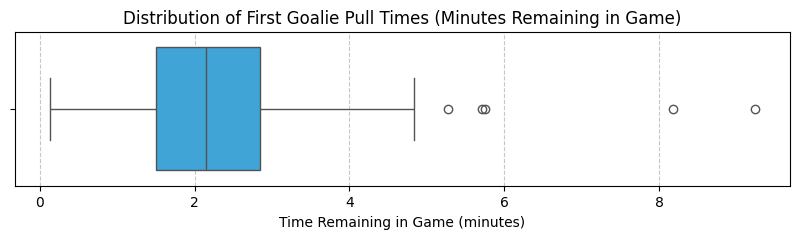

Average (Mean) First Goalie Pull Time: 2.45 minutes remaining in game
Median First Goalie Pull Time: 2.14 minutes remaining in game

Full Summary Statistics for First Goalie Pull Times (Minutes Remaining):
count    82.000000
mean      2.449593
std       1.501129
min       0.133333
25%       1.504167
50%       2.141667
75%       2.845833
max       9.233333
Name: minutes_remaining_in_game, dtype: float64


In [ ]:
# Call the function with your goalie_pulls_df
plot_first_goalie_pull_times(goalie_pulls_df.copy()) # Use a copy to avoid modifying the original df outside the function if temporary columns are added


--- Boston Fleet ---
Average (Mean) First Goalie Pull Time: 2.79 minutes remaining in game
Median First Goalie Pull Time: 1.27 minutes remaining in game
Full Summary Statistics:
count    6.000000
mean     2.791667
std      3.219916
min      1.033333
25%      1.183333
50%      1.266667
75%      2.412500
max      9.233333
Name: minutes_remaining_in_game, dtype: float64

--- Ottawa Charge ---
Average (Mean) First Goalie Pull Time: 2.02 minutes remaining in game
Median First Goalie Pull Time: 1.72 minutes remaining in game
Full Summary Statistics:
count    12.000000
mean      2.022222
std       0.934451
min       0.883333
25%       1.420833
50%       1.716667
75%       2.708333
max       3.833333
Name: minutes_remaining_in_game, dtype: float64

--- Toronto Sceptres ---
Average (Mean) First Goalie Pull Time: 2.55 minutes remaining in game
Median First Goalie Pull Time: 1.83 minutes remaining in game
Full Summary Statistics:
count    11.000000
mean      2.550000
std       1.628650
min      

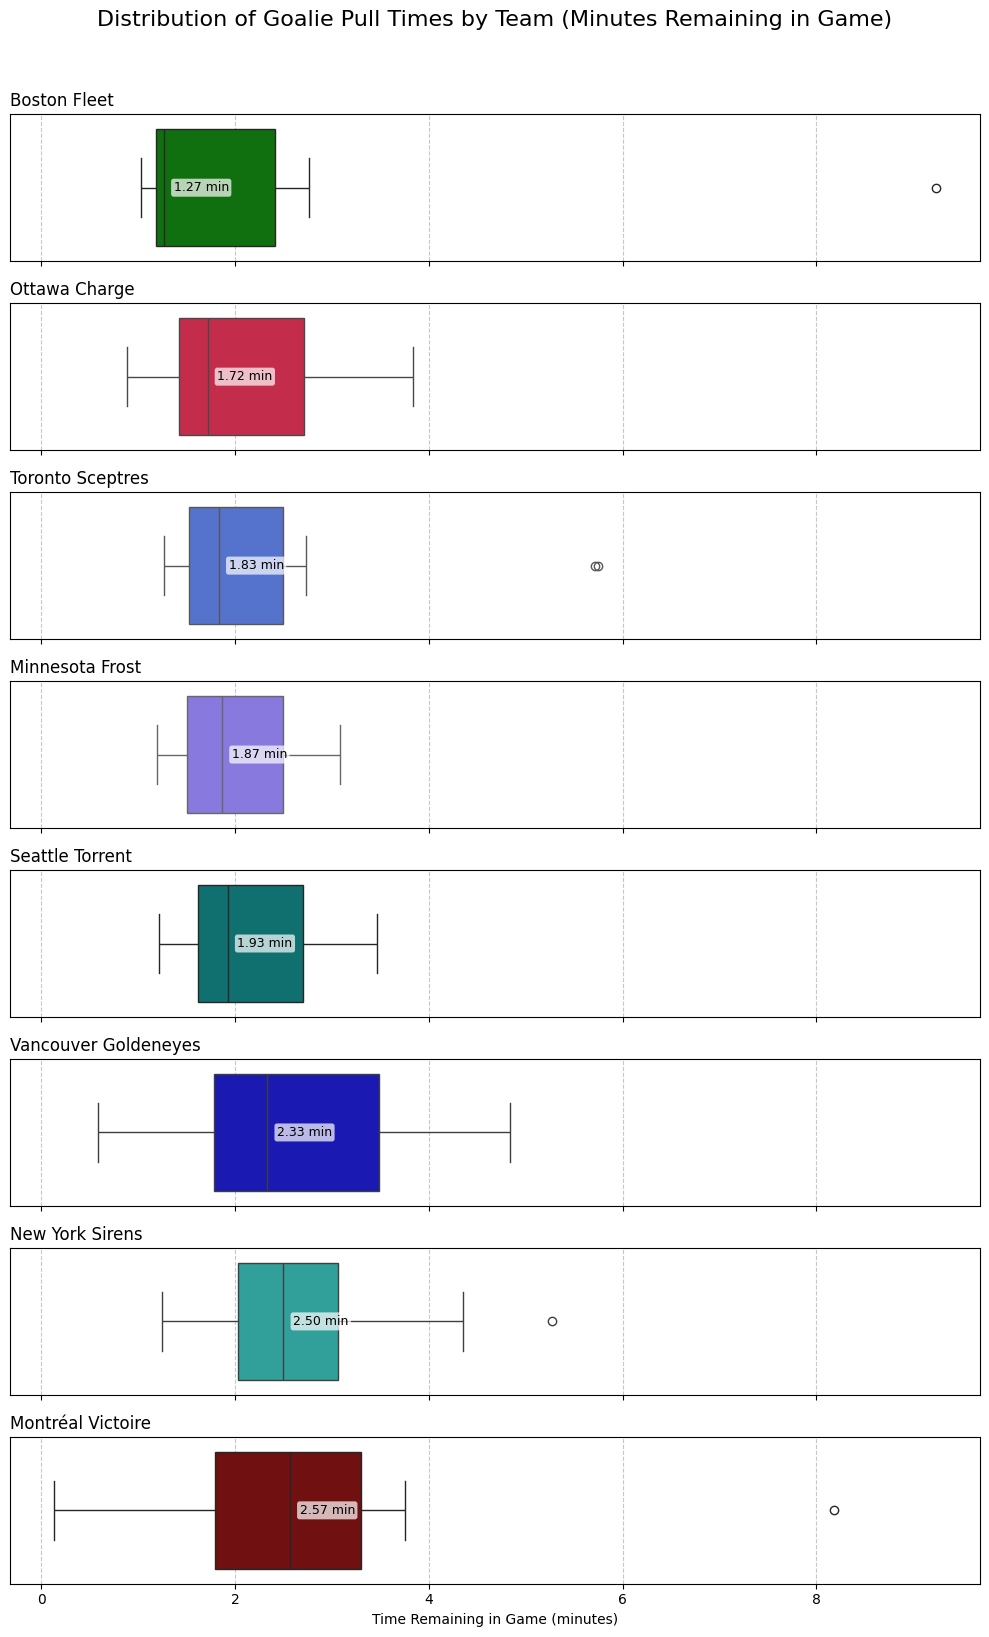

In [ ]:

def plot_goalie_pull_times_by_team(df, team_name_col):
    """
    Generates horizontal box plots of the first goalie pull times (in minutes remaining in the game)
    for each team, sorted by median pull time, and prints summary statistics for each team.
    Uses `team_color_map` for colors and labels the median on each plot.

    Args:
        df (pd.DataFrame): The DataFrame containing goalie pull data with
                           'time_remaining', 'period_id', 'game_id', and a team_name_col.
        team_name_col (str): The name of the column containing team names.
    """

    # Ensure required columns are present
    required_cols = ['time_remaining', 'period_id', 'game_id', team_name_col]
    if not all(col in df.columns for col in required_cols):
        print(f"Error: Missing one or more required columns in DataFrame. Required: {required_cols}")
        return

    # Convert time_remaining and period_id to a single 'time from start of game' metric
    df_temp = df.copy()
    df_temp['time_from_start_of_period'] = 20 - df_temp['time_remaining']
    df_temp['total_time_from_game_start'] = (df_temp['period_id'] - 1) * 20 + df_temp['time_from_start_of_period']

    # For each game and team, find the earliest goalie pull time
    first_pull_times_by_game_team = df_temp.groupby(['game_id', team_name_col])['total_time_from_game_start'].min().reset_index()

    # Calculate minutes remaining from the total game time (60 minutes)
    first_pull_times_by_game_team['minutes_remaining_in_game'] = 60 - first_pull_times_by_game_team['total_time_from_game_start']

    # Calculate median pull times for each team and sort teams by median
    median_pull_times_series = first_pull_times_by_game_team.groupby(team_name_col)['minutes_remaining_in_game'].median().sort_values(ascending=True)
    unique_teams_sorted = median_pull_times_series.index.tolist()
    num_teams = len(unique_teams_sorted)

    # Create subplots for each team
    fig, axes = plt.subplots(num_teams, 1, figsize=(10, 2 * num_teams), sharex=True)
    if num_teams == 1: # Handle case of single team to avoid indexing error for axes
        axes = [axes]

    fig.suptitle('Distribution of Goalie Pull Times by Team (Minutes Remaining in Game)', fontsize=16, y=1.02)

    for i, team in enumerate(unique_teams_sorted):
        team_pull_times = first_pull_times_by_game_team[first_pull_times_by_game_team[team_name_col] == team]

        # Use team_color_map for colors
        plot_color = team_color_map.get(team, 'gray') # Default to gray if team not in map
        sns.boxplot(x=team_pull_times['minutes_remaining_in_game'], ax=axes[i], color=plot_color)

        axes[i].set_title(f'{team}', loc='left')
        axes[i].set_ylabel('') # Remove y-axis label for horizontal plot
        axes[i].set_yticks([]) # Remove y-axis ticks
        axes[i].grid(axis='x', linestyle='--', alpha=0.7)

        # Label the median on the plot
        median_val = median_pull_times_series[team]
        axes[i].text(median_val + 0.1, 0, f'{median_val:.2f} min', va='center', ha='left', color='black', fontsize=9,
                     bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2'))

        # Print summary statistics for each team
        mean_pull_time = team_pull_times['minutes_remaining_in_game'].mean()

        print(f"\n--- {team} ---")
        print(f"Average (Mean) First Goalie Pull Time: {mean_pull_time:.2f} minutes remaining in game")
        print(f"Median First Goalie Pull Time: {median_val:.2f} minutes remaining in game")
        print("Full Summary Statistics:")
        print(team_pull_times['minutes_remaining_in_game'].describe())

    plt.xlabel('Time Remaining in Game (minutes)') # Set common x-label
    plt.tight_layout()
    plt.show()

# Call the function with your goalie_pulls_df and appropriate columns
# Using 'pulling_team_name' as the team column
plot_goalie_pull_times_by_team(goalie_pulls_df.copy(), 'pulling_team_name')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_goalie_pull_beeswarm(df, time_col='time_remaining', goal_col='scored_extra_attacker_goal',
                                figsize=(8, 6), point_size=4, palette=None, ax=None):
    """
    Beeswarm plot of goalie pull times, split by whether an extra-attacker goal was scored.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    order = [False, True]
    palette = palette or ['#8c8c8c', '#d62728']

    sns.swarmplot(
        data=df,
        x=goal_col,
        y=time_col,
        order=order,
        hue=goal_col,
        hue_order=order,
        size=point_size,
        palette=palette,
        legend=False,
        ax=ax,
    )

    # overlay group means as reference lines
    means = df.groupby(goal_col)[time_col].mean().reindex(order)
    for i, m in enumerate(means):
        ax.hlines(m, i - 0.25, i + 0.25, colors='black', linewidth=1.5, zorder=5)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No EA Goal', 'EA Goal Scored'])
    ax.set_xlabel('')
    ax.set_ylabel('Time Remaining (minutes)')
    ax.set_title('Beeswarm Plot of Goalie Pull Times')
    sns.despine(ax=ax)
    return ax


In [ ]:
def plot_goalie_pull_beeswarm_2(df, time_col='time_remaining', goal_col='scored_extra_attacker_goal',
                                figsize=(8, 5), point_size=4, palette=None, ax=None):
    """
    Beeswarm plot of goalie pull times, split by whether an extra-attacker goal was scored.
    Time on x-axis, EA Goal Scored on top, No EA Goal on bottom.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    order = [True, False]  # top to bottom
    palette = palette or ['#d62728', '#8c8c8c']

    sns.swarmplot(
        data=df,
        x=time_col,
        y=goal_col,
        order=order,
        hue=goal_col,
        hue_order=order,
        size=point_size,
        palette=palette,
        legend=False,
        ax=ax,
    )

    means = df.groupby(goal_col)[time_col].mean().reindex(order)
    for i, m in enumerate(means):
        ax.vlines(m, i - 0.25, i + 0.25, colors='black', linewidth=1.5, zorder=5)

    ax.set_yticks([0, 1])
    ax.set_yticklabels(['EA Goal Scored', 'No EA Goal'])
    ax.set_ylabel('')
    ax.set_xlabel('Time Remaining (minutes)')
    ax.set_title('Beeswarm Plot of Goalie Pull Times')
    sns.despine(ax=ax)
    return ax

In [ ]:
def plot_goalie_pull_beeswarm(df, time_col='time_remaining', goal_col='scored_extra_attacker_goal',
                                figsize=(8, 5), point_size=4, palette=None, ax=None):
    """
    Beeswarm plot of goalie pull times, split by whether an extra-attacker goal was scored.
    Time on x-axis, EA Goal Scored on top, No EA Goal on bottom.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # bool dtype + hue on the same column silently drops points in seaborn's
    # swarmplot, so map to string labels first
    label_col = f'_{goal_col}_label'
    df = df.copy()
    df[label_col] = df[goal_col].map({True: goal_col +": true", False: goal_col +": false"})

    order = [goal_col +": true", goal_col +": false"]  # top to bottom
    palette = palette or ['#d62728', '#8c8c8c']

    sns.swarmplot(
        data=df,
        x=time_col,
        y=label_col,
        order=order,
        hue=label_col,
        hue_order=order,
        size=point_size,
        palette=palette,
        legend=False,
        ax=ax,
    )

    means = df.groupby(label_col)[time_col].mean().reindex(order)
    for i, m in enumerate(means):
        ax.vlines(m, i - 0.25, i + 0.25, colors='black', linewidth=1.5, zorder=5)

    ax.set_ylabel('')
    ax.set_xlabel('Time Remaining (minutes)')
    ax.set_title('Beeswarm Plot of Goalie Pull Times')
    sns.despine(ax=ax)
    return ax

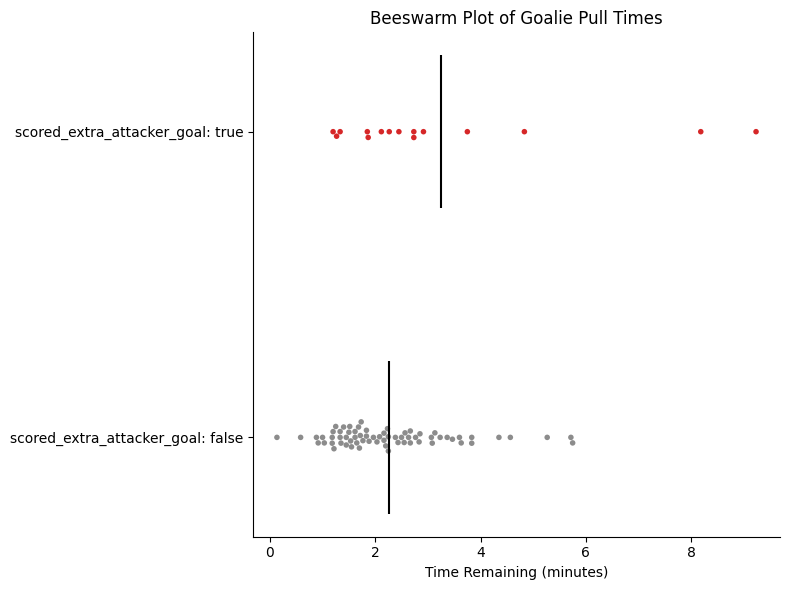

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_goalie_pull_beeswarm(goalie_pulls_df, ax=ax)
plt.tight_layout()
plt.show()

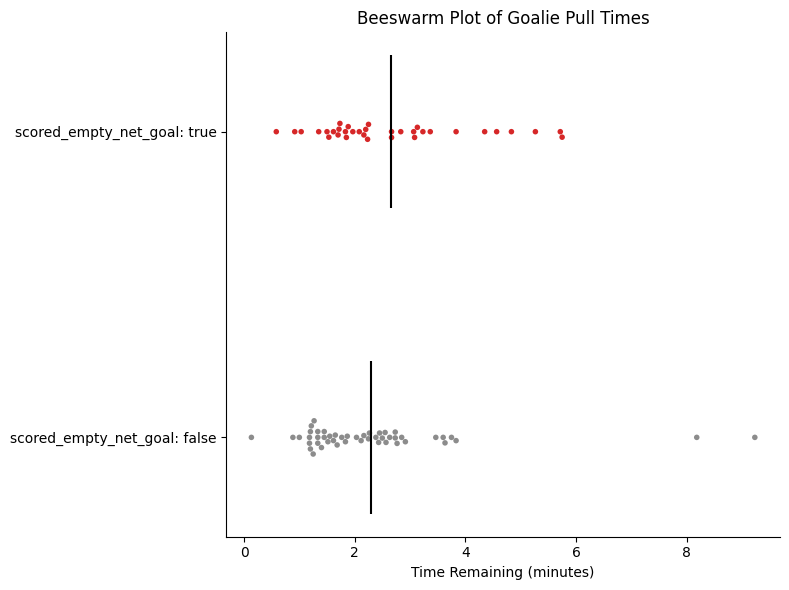

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_goalie_pull_beeswarm(goalie_pulls_df, ax=ax, goal_col = 'scored_empty_net_goal')
plt.tight_layout()
plt.show()

Does power play efficiency correspond to empty net success?

In [ ]:
pip install requests

In [ ]:
import requests
def get_standings_for_season(season_id):
  standings_response = requests.get("https://lscluster.hockeytech.com/feed/index.php?feed=modulekit&view=statviewtype&stat=conference&type=standings&season_id="+str(season_id) +"&key=446521baf8c38984&client_code=pwhl")
  if standings_response.status_code != 200:
    return None

  standings_json = standings_response.json()
  standings_json_stats = standings_json["SiteKit"]["Statviewtype"]


  # Load the JSON file into a DataFrame
  standings_df = pd.json_normalize(standings_json_stats[1:])
  standings_df_short = standings_df[['team_id', 'city', 'nickname', 'power_play_pct', 'goals_for' ]]

  return standings_df_short

In [ ]:
season_to_id_map = {
    "2024": 1,
    "2024-2025": 5,
    "2025-2026": 8,
    "2026-2027": 10,
}

In [ ]:
standings_2025 = get_standings_for_season(season_to_id_map["2025-2026"])

In [ ]:
standings_2025.head()

,team_id,city,nickname,power_play_pct,goals_for
0,3,Montréal,Victoire,19.3,78
1,1,Boston,Fleet,14.0,74
2,2,Minnesota,Frost,23.0,91
3,5,Ottawa,Charge,17.8,71
4,6,Toronto,Sceptres,10.8,51


# Interesting Cases


*   3/14/26 - Earliest goalie pull is Fleet pulling their goalie with 9 mins left vs Victoire. They were battling with Victoire for first place. Game id 286
*   4/15/26 - Sirens pull their goalie despite being tied to try to defeat Toronto in regulation. End of the season. Game id 316
*   4/21/26 - Victoire vs Goldeneyes. Victoire pulls goalie with 8 left and Scamurra gets a hat trick, all empty net goals. Game id 323

## Other context


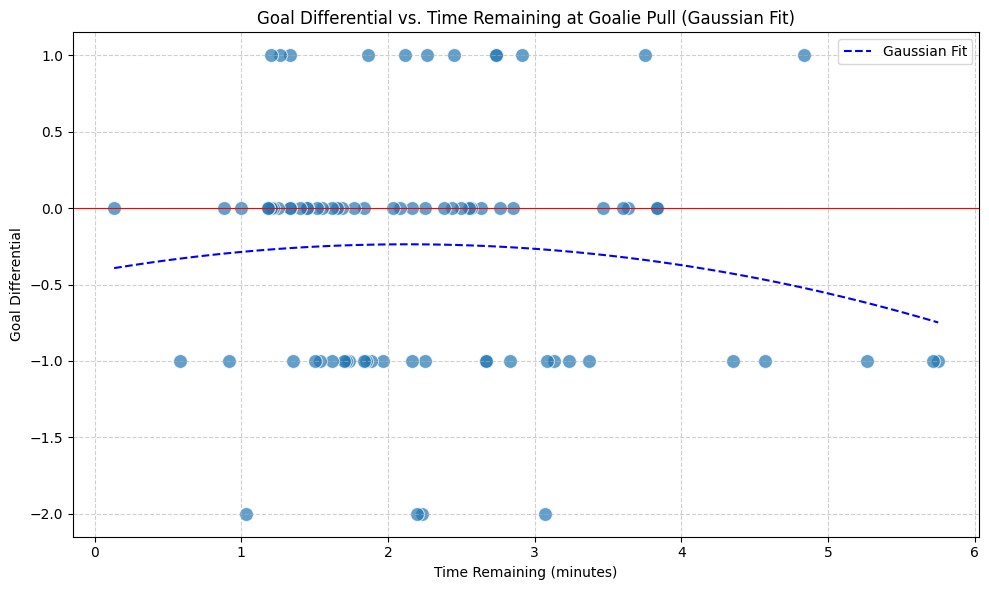

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.optimize import curve_fit

plt.figure(figsize=(10, 6))

# Assuming 'pull_time_minutes' is minutes from the start of the game
# Calculate 'minutes_remaining_in_game'
goal_differential_df['minutes_remaining_in_game'] = 60 - goal_differential_df['pull_time_minutes']

# Filter out NaN values from the relevant columns for plotting
plot_data_filtered = goal_differential_df.dropna(subset=['minutes_remaining_in_game', 'goal_differential_after_pull'])

# Identify and remove the top 2 outliers based on 'minutes_remaining_in_game'
# Sort in descending order to get the highest 'minutes_remaining_in_game' values
plot_data_filtered = plot_data_filtered.sort_values(by='minutes_remaining_in_game', ascending=False)
plot_data_filtered_no_outliers = plot_data_filtered.iloc[2:] # Exclude the top 2 rows

sns.scatterplot(data=plot_data_filtered_no_outliers, x='minutes_remaining_in_game', y='goal_differential_after_pull', s=100, alpha=0.7)

# Define a Gaussian function for fitting
def gaussian(x, a, mu, sigma, offset):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

# Extract data for fitting
x_data = plot_data_filtered_no_outliers['minutes_remaining_in_game'].values
y_data = plot_data_filtered_no_outliers['goal_differential_after_pull'].values

# Initial guess for parameters (amplitude, mean, std dev, offset)
# Estimate based on the data: amplitude can be around the range of y_data, mean around middle of x_data
# std dev can be spread of x_data, offset around 0
initial_guess = [
    np.max(y_data) - np.min(y_data),  # Amplitude
    np.mean(x_data),                  # Mean
    np.std(x_data),                   # Standard deviation
    np.min(y_data)                    # Offset
]

# Fit the Gaussian function to the data
try:
    params, covariance = curve_fit(gaussian, x_data, y_data, p0=initial_guess)
    # Generate points for the fitted curve
    x_fit = np.linspace(np.min(x_data), np.max(x_data), 100)
    y_fit = gaussian(x_fit, *params)
    plt.plot(x_fit, y_fit, color='blue', linestyle='--', label='Gaussian Fit')
except RuntimeError:
    print("Could not fit Gaussian curve. Trying a simpler approach.")
    # Fallback if Gaussian fit fails, although less likely with this data
    sns.regplot(data=plot_data_filtered_no_outliers, x='minutes_remaining_in_game', y='goal_differential_after_pull',
                order=3, scatter=False, color='blue', line_kws={'linestyle':'--'},
                label='Polynomial (Order 3) Fit')

plt.title('Goal Differential vs. Time Remaining at Goalie Pull (Gaussian Fit)')
plt.xlabel('Time Remaining (minutes)')
plt.ylabel('Goal Differential')
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(0, color='red', linestyle='-', linewidth=0.8) # Add a line for 0 goal differential
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Sort the DataFrame by 'time_remaining' in descending order to find the earliest pulls
# A higher 'time_remaining' value means the pull happened earlier in the game.
earliest_goalie_pulls = goalie_pulls_df.sort_values(by='time_remaining', ascending=False).head(5)

# Display relevant information for the earliest pulls
print("5 Earliest Goalie Pulls:")
print(earliest_goalie_pulls[['game_id', 'game_date', 'pulling_team_name', 'goalie_out_info.last_name', 'time', 'period_id']])

5 Earliest Goalie Pulls:
    game_id                   game_date  pulling_team_name  \
52      286      Sunday, March 15, 2026       Boston Fleet   
78      323     Tuesday, April 21, 2026  Montréal Victoire   
22      241  Tuesday, December 30, 2025   Toronto Sceptres   
80      328    Saturday, April 25, 2026   Toronto Sceptres   
81      329    Saturday, April 25, 2026    New York Sirens   

   goalie_out_info.last_name   time  period_id  
52                   Frankel  10:46          3  
78                Abstreiter  11:49          3  
22                      Kirk  14:15          3  
80                      Kirk  14:17          3  
81                  Shanahan  14:44          3  


In [ ]:
team_extra_attacker_no_eng_pct = []

for team_name in goalie_pulls_df['pulling_team_name'].unique():
    team_df = goalie_pulls_df[goalie_pulls_df['pulling_team_name'] == team_name]

    # Case: Extra Attacker Goal & No Empty Net Goal
    extra_attacker_no_eng_count = team_df[(team_df['scored_extra_attacker_goal'] == True) & (team_df['scored_empty_net_goal'] == False)].shape[0]
    total_pulls = team_df.shape[0]

    if total_pulls > 0:
        extra_attacker_no_eng_percent = (extra_attacker_no_eng_count / total_pulls) * 100
    else:
        extra_attacker_no_eng_percent = 0

    team_extra_attacker_no_eng_pct.append({
        'team_name': team_name,
        'extra_attacker_no_eng_pct': extra_attacker_no_eng_percent
    })

extra_attacker_no_eng_df = pd.DataFrame(team_extra_attacker_no_eng_pct)
display(extra_attacker_no_eng_df)

,team_name,extra_attacker_no_eng_pct
0,Minnesota Frost,42.857143
1,Vancouver Goldeneyes,14.285714
2,Ottawa Charge,8.333333
3,Montréal Victoire,42.857143
4,New York Sirens,0.000000
5,Seattle Torrent,8.333333
6,Toronto Sceptres,18.181818
7,Boston Fleet,16.666667


In [ ]:
# Prepare standings_2025 team names to match goalie_pulls_df
standings_2025['full_team_name'] = standings_2025['city'] + ' ' + standings_2025['nickname']

# Merge the two DataFrames
merged_df = pd.merge(extra_attacker_no_eng_df,
                     standings_2025[['full_team_name', 'power_play_pct']],
                     left_on='team_name',
                     right_on='full_team_name',
                     how='left')

# Drop the redundant 'full_team_name' column
merged_df = merged_df.drop(columns=['full_team_name'])

display(merged_df)

,team_name,extra_attacker_no_eng_pct,power_play_pct
0,Minnesota Frost,42.857143,23.0
1,Vancouver Goldeneyes,14.285714,10.7
2,Ottawa Charge,8.333333,17.8
3,Montréal Victoire,42.857143,19.3
4,New York Sirens,0.000000,12.8
5,Seattle Torrent,8.333333,15.7
6,Toronto Sceptres,18.181818,10.8
7,Boston Fleet,16.666667,14.0


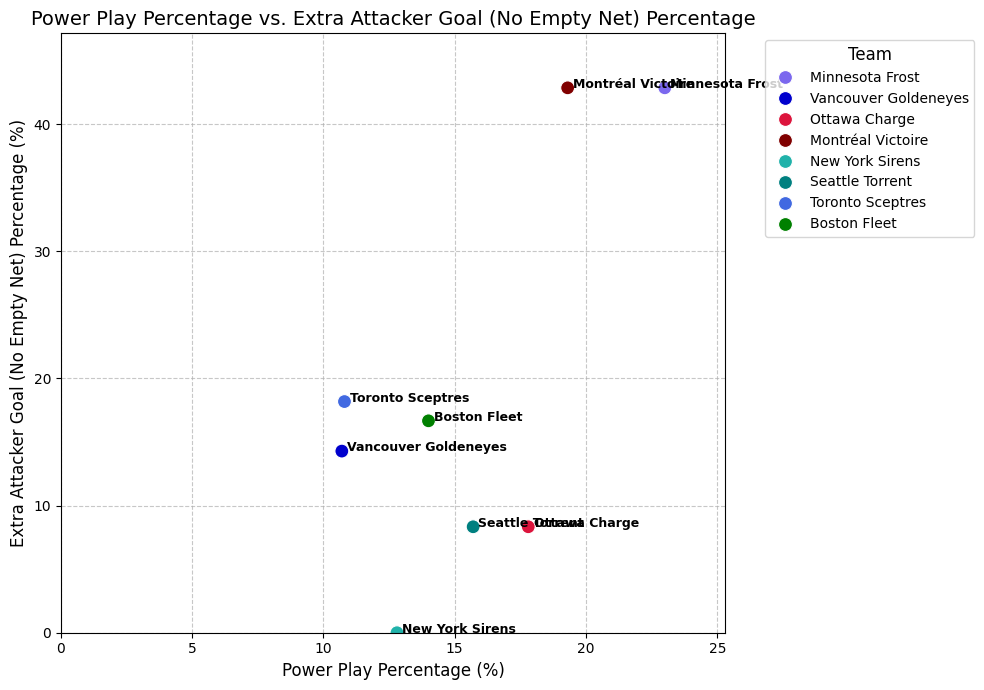

In [ ]:
plt.figure(figsize=(10, 7)) # Changed figure size to make it wider

# Ensure 'power_play_pct' is numeric before plotting and arithmetic operations
merged_df['power_play_pct'] = pd.to_numeric(merged_df['power_play_pct'], errors='coerce')

# Create a palette from team_color_map for the teams present in merged_df
plot_palette = {team: team_color_map.get(team, 'gray') for team in merged_df['team_name'].unique()}

sns.scatterplot(data=merged_df,
                x='power_play_pct',
                y='extra_attacker_no_eng_pct',
                hue='team_name',
                palette=plot_palette, # Use the custom palette
                s=100) # s controls marker size

# Add labels to each point, using the full team name again
for line in range(0, merged_df.shape[0]):
     plt.text(merged_df['power_play_pct'][line] + 0.2,
              merged_df['extra_attacker_no_eng_pct'][line],
              merged_df['team_name'][line], horizontalalignment='left',
              size=9, color='black', weight='semibold') # Adjusted label size

plt.title('Power Play Percentage vs. Extra Attacker Goal (No Empty Net) Percentage', fontsize=14) # Increased title font size
plt.xlabel('Power Play Percentage (%)', fontsize=12) # Increased x-label font size
plt.ylabel('Extra Attacker Goal (No Empty Net) Percentage (%)', fontsize=12) # Increased y-label font size
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12) # Adjusted legend font sizes

# Set x and y axis limits to start at 0
plt.xlim(0, merged_df['power_play_pct'].max() * 1.1) # Extend a bit beyond max for readability
plt.ylim(0, merged_df['extra_attacker_no_eng_pct'].max() * 1.1) # Extend a bit beyond max for readability

plt.tight_layout()
plt.show()

To use team logos as markers, we first need a mapping from team names to their respective image URLs or local file paths. Then, we can use `matplotlib.offsetbox.AnnotationBbox` to place these images at each scatter plot point.

Let's assume you've provided a dictionary `team_logo_urls` where keys are `team_name` and values are URLs/paths to the logos. If your logos are hosted on GitHub, you can use raw GitHub URLs. If they are in your Colab environment, make sure to upload them to a directory (e.g., `/content/logos/`) and provide the local paths.

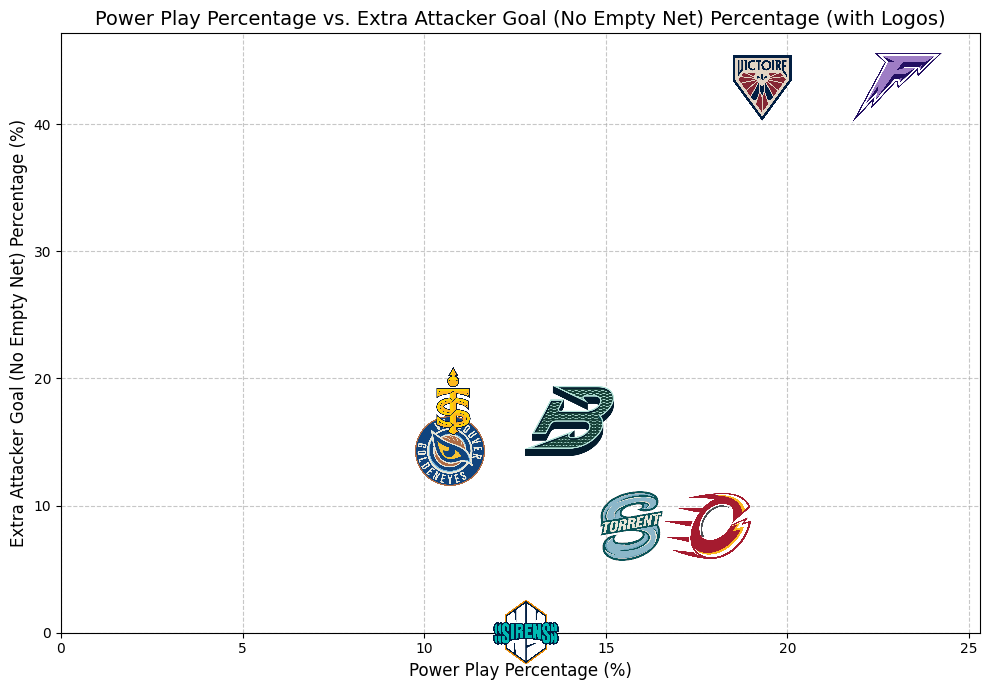

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import urllib.request # To handle image URLs
from PIL import Image # For opening images
import numpy as np

# --- team_logo_urls updated with raw GitHub URLs ---
base_logo_url = 'https://raw.githubusercontent.com/365hockeygirl/pwhl-pulling-the-goalie/d8e6d9d0ddfeb83396d16b3f8aed6add64e98828/pwhl_logos/'
team_logo_urls = {
    'Minnesota Frost': base_logo_url + 'Minnesota%20Frost.png',
    'Vancouver Goldeneyes': base_logo_url + 'Vancouver%20Goldeneyes.png',
    'Ottawa Charge': base_logo_url + 'Ottawa%20Charge.png',
    'Montréal Victoire': base_logo_url + 'Montreal%20Victoire.png',
    'New York Sirens': base_logo_url + 'New%20York%20Sirens.png',
    'Seattle Torrent': base_logo_url + 'Seattle%20Torrent.png',
    'Toronto Sceptres': base_logo_url + 'Toronto%20Sceptres.png',
    'Boston Fleet': base_logo_url + 'Boston%20Fleet.png',
}

# --- Load and resize logos ---
# This function will attempt to load an image from a URL or local path.
def get_image(path, target_height_pixels=50): # Normalize image height to a fixed pixel size
    try:
        if path.startswith('http'):
            with urllib.request.urlopen(path) as url:
                img = Image.open(url)
        else: # Assume local file path
            img = Image.open(path)

        # Calculate zoom based on target height and original image height
        original_width, original_height = img.size
        zoom_factor = target_height_pixels / original_height

        # Convert to RGBA for consistent plotting
        return OffsetImage(np.array(img.convert('RGBA')), zoom=zoom_factor)
    except Exception as e:
        print(f"Could not load image from {path}: {e}")
        return None # Return None if image fails to load

plt.figure(figsize=(10, 7))
ax = plt.gca() # Get current axes

# Ensure 'power_play_pct' is numeric
merged_df['power_play_pct'] = pd.to_numeric(merged_df['power_play_pct'], errors='coerce')

# Plotting using AnnotationBbox for logos
for index, row in merged_df.iterrows():
    team_name = row['team_name']
    x = row['power_play_pct']
    y = row['extra_attacker_no_eng_pct']
    logo_path = team_logo_urls.get(team_name) # Get the logo path for the current team

    if logo_path: # Only plot if a logo path exists
        oi = get_image(logo_path, target_height_pixels=50) # Use target_height_pixels to normalize size
        if oi: # Only proceed if image was successfully loaded
            ab = AnnotationBbox(oi, (x, y), frameon=False, pad=0.0, xycoords='data')
            ax.add_artist(ab)
    else:
        # Fallback to a scatter point if logo is not found or fails to load
        ax.scatter(x, y, color='gray', s=100, label=team_name if team_name not in ax.get_legend_handles_labels()[1] else "")

# Add labels to each point (optional, as logos provide identification)
# for line in range(0, merged_df.shape[0]):
#      plt.text(merged_df['power_play_pct'][line] + 0.5,
#               merged_df['extra_attacker_no_eng_pct'][line],
#               merged_df['team_name'][line], horizontalalignment='left',
#               size=9, color='black', weight='semibold')

plt.title('Power Play Percentage vs. Extra Attacker Goal (No Empty Net) Percentage (with Logos)', fontsize=14)
plt.xlabel('Power Play Percentage (%)', fontsize=12)
plt.ylabel('Extra Attacker Goal (No Empty Net) Percentage (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Since AnnotationBbox doesn't automatically create legend entries, we can create a dummy legend
# Or you might choose to remove the legend if the logos are self-explanatory
# If you still want a legend, you'll need to manually create patches/handles for it.
# For now, I'll remove the previous legend to avoid clutter with logos.
# plt.legend(title='Team', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)

# Set x and y axis limits to start at 0
plt.xlim(0, merged_df['power_play_pct'].max() * 1.1)
plt.ylim(0, merged_df['extra_attacker_no_eng_pct'].max() * 1.1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1000/735576886.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




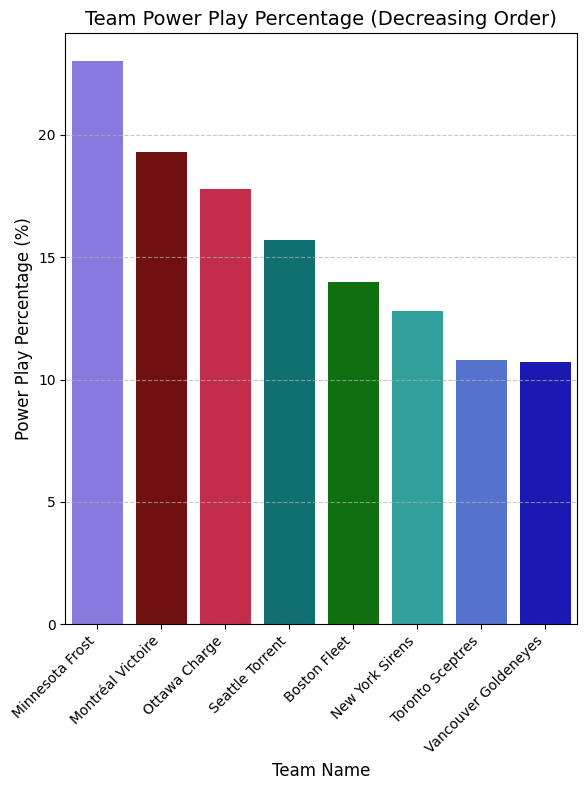

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the merged_df by 'power_play_pct' in descending order
sorted_df = merged_df.sort_values(by='power_play_pct', ascending=False)

plt.figure(figsize=(6, 8)) # Changed to 4:3 vertical aspect ratio

# Create a palette from team_color_map for the teams present in sorted_df
plot_palette = {team: team_color_map.get(team, 'gray') for team in sorted_df['team_name'].unique()}

sns.barplot(x='team_name', y='power_play_pct', data=sorted_df, palette=plot_palette)

plt.title('Team Power Play Percentage (Decreasing Order)', fontsize=14) # Increased title font size
plt.xlabel('Team Name', fontsize=12) # Increased x-label font size
plt.ylabel('Power Play Percentage (%)', fontsize=12) # Increased y-label font size
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels and increase font size for better readability
plt.yticks(fontsize=10) # Increased y-tick font size
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

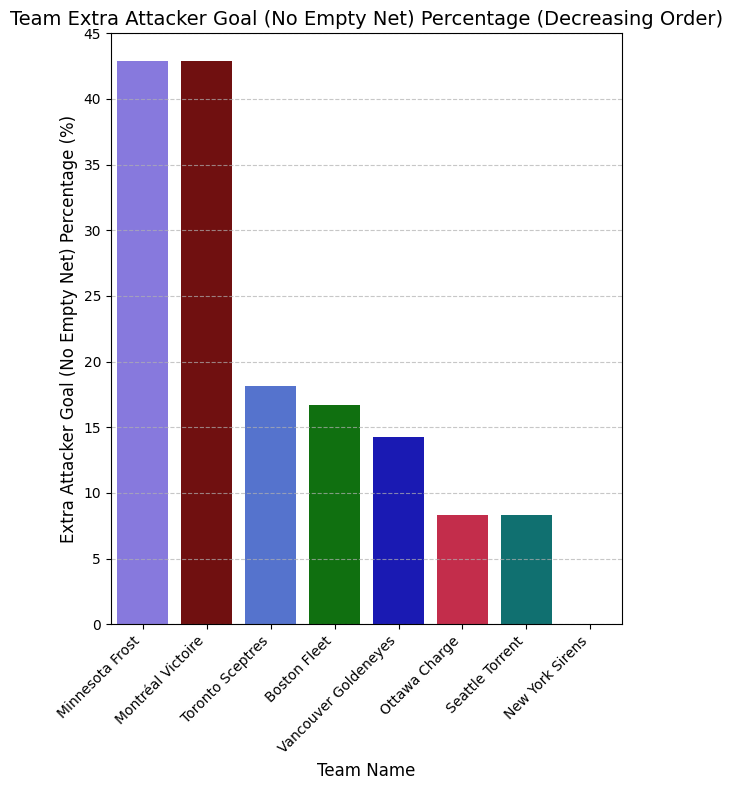

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by 'extra_attacker_no_eng_pct' in descending order
sorted_eag_df = extra_attacker_no_eng_df.sort_values(by='extra_attacker_no_eng_pct', ascending=False)

plt.figure(figsize=(6, 8)) # Changed to 4:3 vertical aspect ratio

# Create a palette from team_color_map for the teams present in sorted_eag_df
plot_palette_eag = {team: team_color_map.get(team, 'gray') for team in sorted_eag_df['team_name'].unique()}

sns.barplot(x='team_name', y='extra_attacker_no_eng_pct', data=sorted_eag_df, palette=plot_palette_eag, hue='team_name', legend=False)

plt.title('Team Extra Attacker Goal (No Empty Net) Percentage (Decreasing Order)', fontsize=14) # Increased title font size
plt.xlabel('Team Name', fontsize=12) # Increased x-label font size
plt.ylabel('Extra Attacker Goal (No Empty Net) Percentage (%)', fontsize=12) # Increased y-label font size
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels and increase font size for better readability
plt.yticks(fontsize=10) # Increased y-tick font size
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

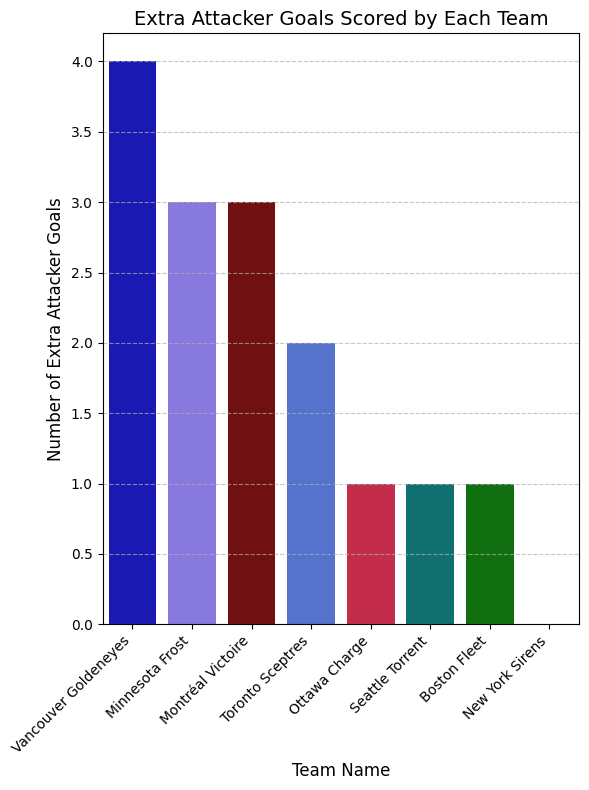

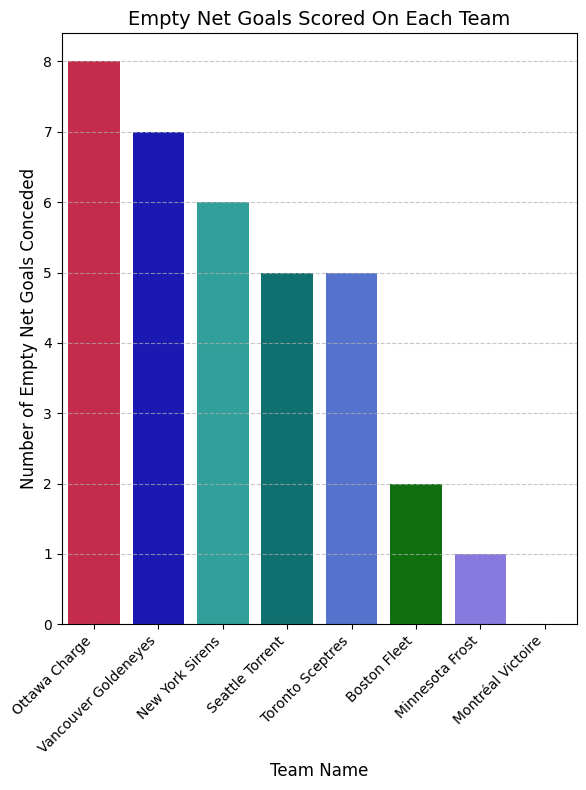

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get all unique team names from the main DataFrame
all_team_names = goalie_pulls_df['pulling_team_name'].unique()

# --- Chart 1: Extra Attacker Goals Scored by Each Team ---

# Filter for cases where an extra attacker goal was scored
extra_attacker_goals_scored = goalie_pulls_df[goalie_pulls_df['scored_extra_attacker_goal'] == True]

# Count extra attacker goals by the pulling team
extra_attacker_counts_raw = extra_attacker_goals_scored['pulling_team_name'].value_counts().reset_index()
extra_attacker_counts_raw.columns = ['team_name', 'extra_attacker_goals_count']

# Create a DataFrame with all teams and merge to ensure zeros are included
extra_attacker_counts = pd.DataFrame(all_team_names, columns=['team_name']).merge(
    extra_attacker_counts_raw, on='team_name', how='left'
).fillna(0) # Fill NaN counts with 0

# Sort in descending order of goal count
extra_attacker_counts_sorted = extra_attacker_counts.sort_values(by='extra_attacker_goals_count', ascending=False)

plt.figure(figsize=(6, 8)) # Mobile-friendly aspect ratio

# Create a palette from team_color_map for the teams present in extra_attacker_counts_sorted
plot_palette_ea = {team: team_color_map.get(team, 'gray') for team in extra_attacker_counts_sorted['team_name'].unique()}

sns.barplot(
    x='team_name',
    y='extra_attacker_goals_count',
    data=extra_attacker_counts_sorted,
    palette=plot_palette_ea,
    hue='team_name', # Explicitly map hue to team_name
    legend=False # Hide the legend as colors are directly mapped to teams on x-axis
)

plt.title('Extra Attacker Goals Scored by Each Team', fontsize=14)
plt.xlabel('Team Name', fontsize=12)
plt.ylabel('Number of Extra Attacker Goals', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- Chart 2: Empty Net Goals Scored on Each Team ---

# Filter for cases where an empty net goal was scored AGAINST the pulling team
empty_net_goals_conceded = goalie_pulls_df[goalie_pulls_df['scored_empty_net_goal'] == True]

# Count empty net goals conceded by the pulling team
empty_net_counts_raw = empty_net_goals_conceded['pulling_team_name'].value_counts().reset_index()
empty_net_counts_raw.columns = ['team_name', 'empty_net_goals_conceded_count']

# Create a DataFrame with all teams and merge to ensure zeros are included
empty_net_counts = pd.DataFrame(all_team_names, columns=['team_name']).merge(
    empty_net_counts_raw, on='team_name', how='left'
).fillna(0) # Fill NaN counts with 0

# Sort in descending order of goal count
empty_net_counts_sorted = empty_net_counts.sort_values(by='empty_net_goals_conceded_count', ascending=False)

plt.figure(figsize=(6, 8)) # Mobile-friendly aspect ratio

# Create a palette from team_color_map for the teams present in empty_net_counts_sorted
plot_palette_en = {team: team_color_map.get(team, 'gray') for team in empty_net_counts_sorted['team_name'].unique()}

sns.barplot(
    x='team_name',
    y='empty_net_goals_conceded_count',
    data=empty_net_counts_sorted,
    palette=plot_palette_en,
    hue='team_name', # Explicitly map hue to team_name
    legend=False # Hide the legend as colors are directly mapped to teams on x-axis
)

plt.title('Empty Net Goals Scored On Each Team', fontsize=14)
plt.xlabel('Team Name', fontsize=12)
plt.ylabel('Number of Empty Net Goals Conceded', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

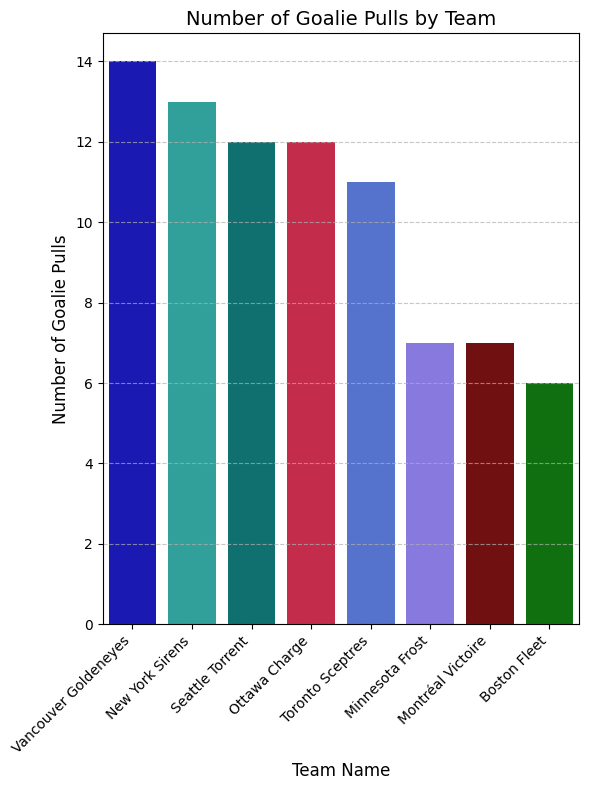

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Count goalie pulls per team
goalie_pull_counts = goalie_pulls_df['pulling_team_name'].value_counts().reset_index()
goalie_pull_counts.columns = ['team_name', 'pull_count']

# Sort in descending order of pull count
goalie_pull_counts_sorted = goalie_pull_counts.sort_values(by='pull_count', ascending=False)

plt.figure(figsize=(6, 8)) # Mobile-friendly aspect ratio

# Create a palette from team_color_map for the teams present in goalie_pull_counts_sorted
plot_palette_pulls = {team: team_color_map.get(team, 'gray') for team in goalie_pull_counts_sorted['team_name'].unique()}

sns.barplot(
    x='team_name',
    y='pull_count',
    data=goalie_pull_counts_sorted,
    palette=plot_palette_pulls,
    hue='team_name', # Explicitly map hue to team_name
    legend=False # Hide the legend as colors are directly mapped to teams on x-axis
)

plt.title('Number of Goalie Pulls by Team', fontsize=14)
plt.xlabel('Team Name', fontsize=12)
plt.ylabel('Number of Goalie Pulls', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

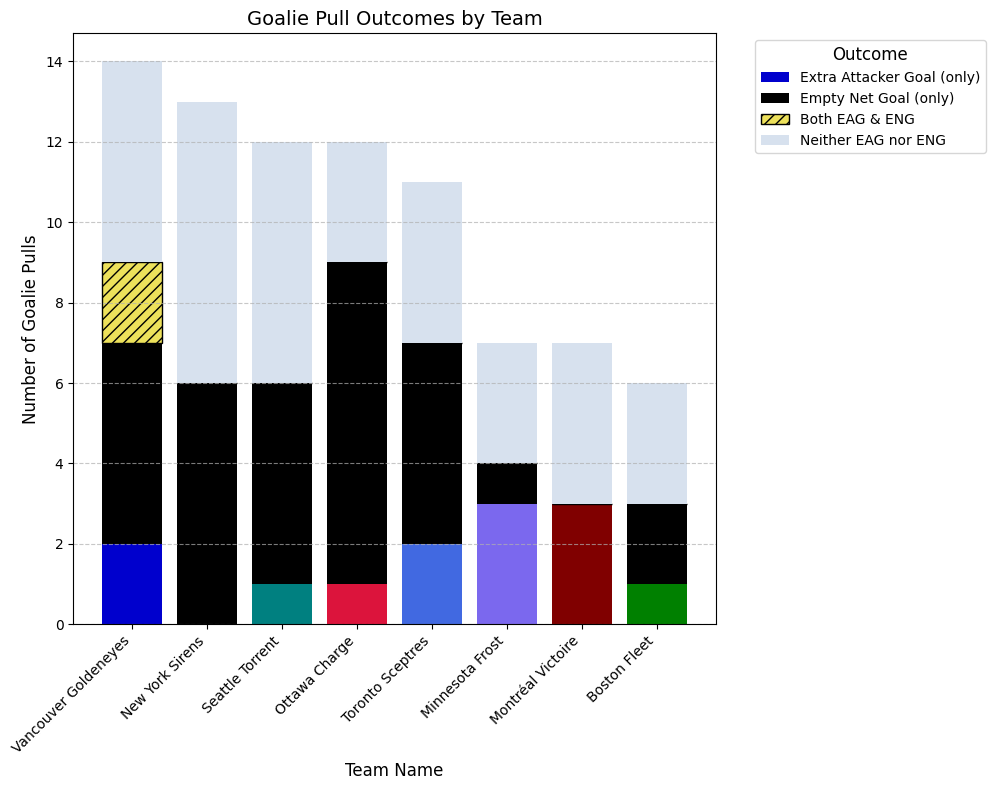

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Get all unique team names from the main DataFrame
all_team_names = goalie_pulls_df['pulling_team_name'].unique()

# Calculate counts for each scenario for all teams
team_outcomes = []
for team_name in all_team_names:
    team_df = goalie_pulls_df[goalie_pulls_df['pulling_team_name'] == team_name]

    eag_only = team_df[(team_df['scored_extra_attacker_goal'] == True) & (team_df['scored_empty_net_goal'] == False)].shape[0]
    eng_only = team_df[(team_df['scored_extra_attacker_goal'] == False) & (team_df['scored_empty_net_goal'] == True)].shape[0]
    both_eag_eng = team_df[(team_df['scored_extra_attacker_goal'] == True) & (team_df['scored_empty_net_goal'] == True)].shape[0]
    neither_eag_eng = team_df[(team_df['scored_extra_attacker_goal'] == False) & (team_df['scored_empty_net_goal'] == False)].shape[0]

    team_outcomes.append({
        'team_name': team_name,
        'eag_only': eag_only,
        'eng_only': eng_only,
        'both_eag_eng': both_eag_eng,
        'neither': neither_eag_eng,
        'total_pulls': eag_only + eng_only + both_eag_eng + neither_eag_eng
    })

outcomes_df = pd.DataFrame(team_outcomes)

# Sort by total pulls for consistency with previous charts
outcomes_df_sorted = outcomes_df.sort_values(by='total_pulls', ascending=False).reset_index(drop=True)

# Define categories for plotting order (bottom to top in stack)
categories = ['eag_only', 'eng_only', 'both_eag_eng', 'neither'] # Reordered as requested
category_labels = {
    'eag_only': 'Extra Attacker Goal (only)',
    'eng_only': 'Empty Net Goal (only)',
    'both_eag_eng': 'Both EAG & ENG',
    'neither': 'Neither EAG nor ENG'
}
category_colors = {
    'eng_only': 'black',
    'both_eag_eng': yellow, # Using 'yellow' from retro_metro palette
    'neither': gray
}
category_hatches = {
    'both_eag_eng': '///' # Hatch for 'Both EAG & ENG'
}

plt.figure(figsize=(10, 8)) # Mobile-friendly aspect ratio, adjusted width for readability
ax = plt.gca()

bar_bottom = [0] * len(outcomes_df_sorted)

for category in categories:
    heights = outcomes_df_sorted[category].tolist()
    labels = outcomes_df_sorted['team_name'].tolist()

    # Get colors dynamically for 'eag_only' or fixed for other categories
    if category == 'eag_only':
        colors = [team_color_map.get(team, 'gray') for team in outcomes_df_sorted['team_name']]
    else:
        colors = [category_colors.get(category, 'lightgray')] * len(outcomes_df_sorted) # Default to lightgray if color not found

    hatch = category_hatches.get(category, None)

    ax.bar(
        x=labels,
        height=heights,
        bottom=bar_bottom,
        color=colors,
        label=category_labels[category],
        hatch=hatch,
        edgecolor='black' if hatch else None # Add edgecolor for hatched bars for better visibility
    )
    # Update bottom for the next stack
    bar_bottom = [b + h for b, h in zip(bar_bottom, heights)]

ax.set_title('Goalie Pull Outcomes by Team', fontsize=14)
ax.set_xlabel('Team Name', fontsize=12)
ax.set_ylabel('Number of Goalie Pulls', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

### Stacked Bar Chart: Extra Attacker Goal (EAG) Only Highlighted

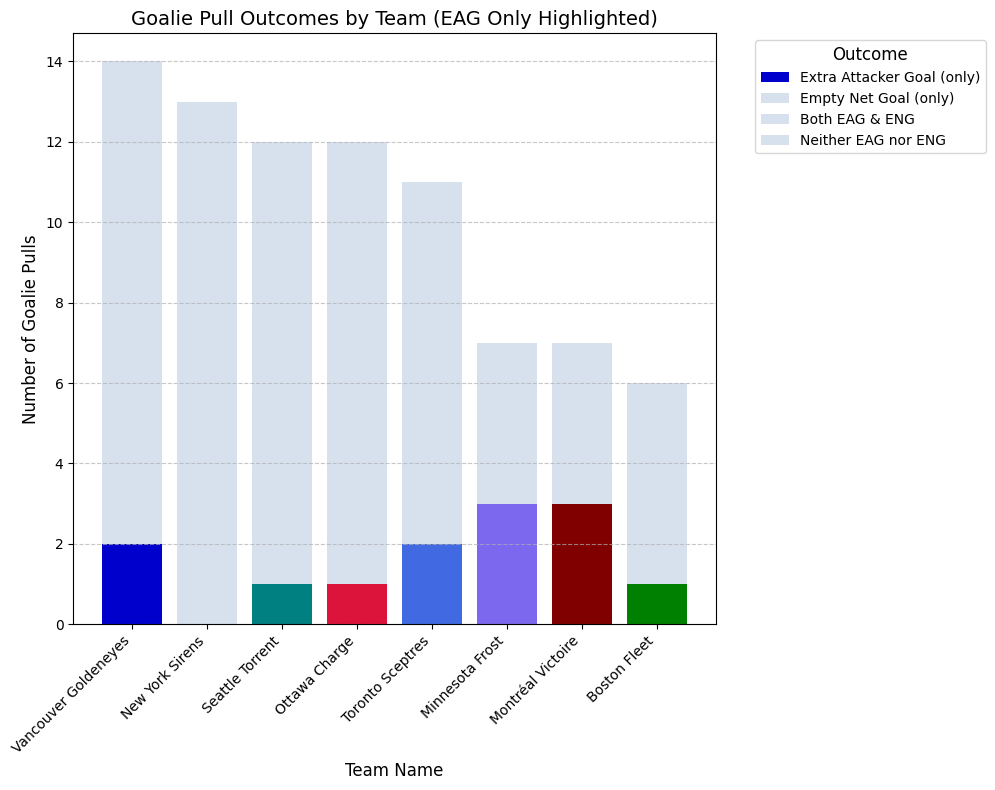

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reuse the outcomes_df_sorted from the previous calculation

# Define categories for plotting order (bottom to top in stack)
categories = ['eag_only', 'eng_only', 'both_eag_eng', 'neither']
category_labels = {
    'eag_only': 'Extra Attacker Goal (only)',
    'eng_only': 'Empty Net Goal (only)',
    'both_eag_eng': 'Both EAG & ENG',
    'neither': 'Neither EAG nor ENG'
}

# Custom colors for this chart: EAG only is team color, others are gray
category_colors_eag_highlight = {
    'eng_only': gray,
    'both_eag_eng': gray,
    'neither': gray # Darker gray as requested for 'neither'
}

category_hatches = {
    # 'both_eag_eng': '///' # Hatch for 'Both EAG & ENG'
}

plt.figure(figsize=(10, 8)) # Mobile-friendly aspect ratio, adjusted width for readability
ax = plt.gca()

bar_bottom = [0] * len(outcomes_df_sorted)

for category in categories:
    heights = outcomes_df_sorted[category].tolist()
    labels = outcomes_df_sorted['team_name'].tolist()

    # Get colors dynamically: team_color_map for 'eag_only', gray for others
    if category == 'eag_only':
        colors = [team_color_map.get(team, 'gray') for team in outcomes_df_sorted['team_name']]
    else:
        colors = [category_colors_eag_highlight.get(category, gray)] * len(outcomes_df_sorted) # Default to gray if color not explicitly defined

    hatch = category_hatches.get(category, None)

    ax.bar(
        x=labels,
        height=heights,
        bottom=bar_bottom,
        color=colors,
        label=category_labels[category],
        hatch=hatch,
        edgecolor='black' if hatch else None # Add edgecolor for hatched bars for better visibility
    )
    # Update bottom for the next stack
    bar_bottom = [b + h for b, h in zip(bar_bottom, heights)]

ax.set_title('Goalie Pull Outcomes by Team (EAG Only Highlighted)', fontsize=14)
ax.set_xlabel('Team Name', fontsize=12)
ax.set_ylabel('Number of Goalie Pulls', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

### Stacked Bar Chart: Empty Net Goal (ENG) Only Highlighted

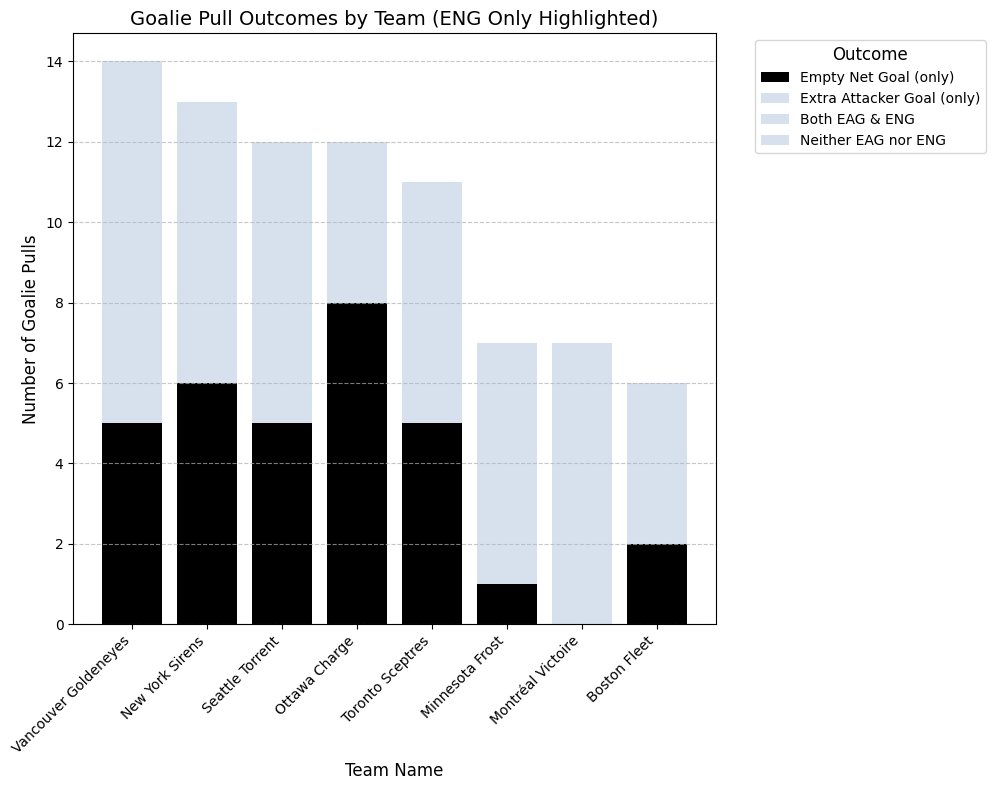

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reuse the outcomes_df_sorted from the previous calculation

# Define categories for plotting order (bottom to top in stack)
categories = ['eng_only', 'eag_only', 'both_eag_eng', 'neither'] # Reordered to put ENG only at the bottom
category_labels = {
    'eag_only': 'Extra Attacker Goal (only)',
    'eng_only': 'Empty Net Goal (only)',
    'both_eag_eng': 'Both EAG & ENG',
    'neither': 'Neither EAG nor ENG'
}

# Custom colors for this chart: ENG only is team color, others are gray
category_colors_eng_highlight = {
    'eng_only': 'black', # Set ENG only to black as requested
    'eag_only': gray,
    'both_eag_eng': gray,
    'neither': gray # Darker gray as requested for 'neither'
}

category_hatches = {
    # 'both_eag_eng': '///' # Hatch for 'Both EAG & ENG'
}

plt.figure(figsize=(10, 8)) # Mobile-friendly aspect ratio, adjusted width for readability
ax = plt.gca()

bar_bottom = [0] * len(outcomes_df_sorted)

for category in categories:
    heights = outcomes_df_sorted[category].tolist()
    labels = outcomes_df_sorted['team_name'].tolist()

    # Get colors dynamically: team_color_map for 'eng_only', gray for others
    colors = [category_colors_eng_highlight.get(category, gray)] * len(outcomes_df_sorted) # Default to gray if color not explicitly defined

    hatch = category_hatches.get(category, None)

    ax.bar(
        x=labels,
        height=heights,
        bottom=bar_bottom,
        color=colors,
        label=category_labels[category],
        hatch=hatch,
        edgecolor='black' if hatch else None # Add edgecolor for hatched bars for better visibility
    )
    # Update bottom for the next stack
    bar_bottom = [b + h for b, h in zip(bar_bottom, heights)]

ax.set_title('Goalie Pull Outcomes by Team (ENG Only Highlighted)', fontsize=14)
ax.set_xlabel('Team Name', fontsize=12)
ax.set_ylabel('Number of Goalie Pulls', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10, title_fontsize=12)
plt.tight_layout()
plt.show()

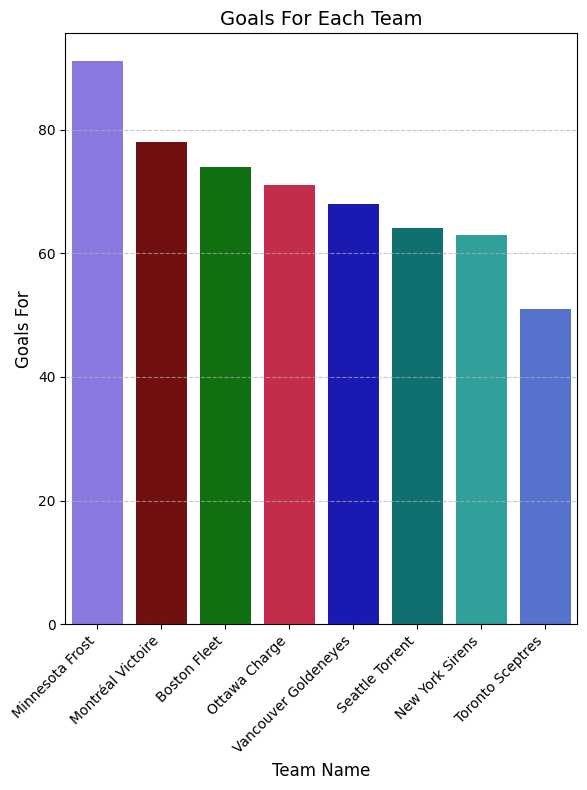

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'goals_for' is numeric
standings_2025['goals_for'] = pd.to_numeric(standings_2025['goals_for'], errors='coerce')

# Create 'full_team_name' column as done previously in the notebook
standings_2025['full_team_name'] = standings_2025['city'] + ' ' + standings_2025['nickname']

# Sort the DataFrame by 'goals_for' in descending order
sorted_standings_df = standings_2025.sort_values(by='goals_for', ascending=False)

plt.figure(figsize=(6, 8)) # Mobile-friendly aspect ratio (4:3 vertical)

# Create a palette from team_color_map for the teams present in sorted_standings_df
plot_palette_goals_for = {team: team_color_map.get(team, 'gray') for team in sorted_standings_df['full_team_name'].unique()}

sns.barplot(
    x='full_team_name',
    y='goals_for',
    data=sorted_standings_df,
    palette=plot_palette_goals_for,
    hue='full_team_name', # Explicitly map hue to full_team_name for correct color mapping
    legend=False # Hide the legend as colors are directly mapped to teams on x-axis
)

plt.title('Goals For Each Team', fontsize=14)
plt.xlabel('Team Name', fontsize=12)
plt.ylabel('Goals For', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10) # Rotate labels for better readability
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()